In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans,MiniBatchKMeans, MeanShift, DBSCAN, AgglomerativeClustering,affinity_propagation
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, QuantileTransformer
from sklearn.decomposition import PCA, KernelPCA
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
import matplotlib.cm as cm
from sklearn.impute import KNNImputer
import matplotlib.ticker as ticker
import warnings 
from sklearn.manifold import TSNE
warnings.filterwarnings('ignore')

In [2]:
import os
os.chdir(r"C:/Users/EG/Documents/Projects/SHAI/Clustering Project/ALL project")

In [3]:
df = pd.read_csv("CC GENERAL.csv")
dff = df.copy()

# 1-EDA:-

In [4]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [5]:
df.shape

(8950, 18)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [7]:
df.dtypes

CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [9]:
dff.drop("CUST_ID", axis=1, inplace=True)
dff.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## 1.1- Checking  missing value

In [10]:
dff.isnull().sum().sort_values(ascending=False)

MINIMUM_PAYMENTS                    313
CREDIT_LIMIT                          1
BALANCE                               0
CASH_ADVANCE_FREQUENCY                0
PRC_FULL_PAYMENT                      0
PAYMENTS                              0
PURCHASES_TRX                         0
CASH_ADVANCE_TRX                      0
PURCHASES_INSTALLMENTS_FREQUENCY      0
BALANCE_FREQUENCY                     0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_FREQUENCY                   0
CASH_ADVANCE                          0
INSTALLMENTS_PURCHASES                0
ONEOFF_PURCHASES                      0
PURCHASES                             0
TENURE                                0
dtype: int64

in a credit limit there's one null value so i will drop it

In [11]:
dff.dropna(subset = 'CREDIT_LIMIT', inplace=True)

## 1.2- Checking The outliers 

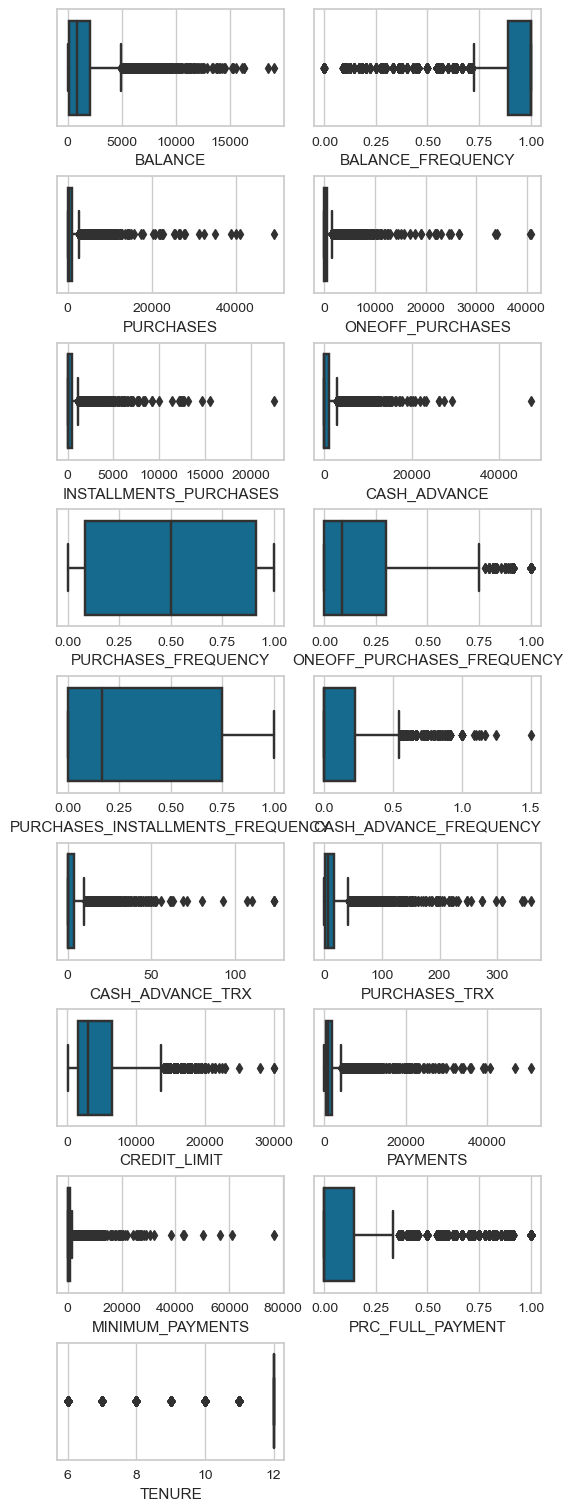

In [12]:
plt.figure(figsize=(5,15), constrained_layout = True)
for i, col in enumerate(dff.columns):
    if dff[col].dtype != 'object':
        ax = plt.subplot(9, 2, i+1)
        sns.boxplot(dff[col], ax=ax)
        plt.xlabel(col)
        
plt.show()

In [13]:
def Detect_outliers_pct(col):
    Q1 = col.quantile(.25)
    Q3 = col.quantile(.75)
    IQR = Q3 - Q1
    
    minimum = Q1-(1.5*IQR)
    maximumm = Q3 + (1.5*IQR)
    
    pct = np.sum((col < minimum) | (col > maximumm))
    return pct

In [14]:
for col in dff.columns:
    ou_pct = Detect_outliers_pct(dff[col])
    print(f"The pct of {col} = {round(ou_pct/len(dff[col])*100,2)}%")

The pct of BALANCE = 7.77%
The pct of BALANCE_FREQUENCY = 16.67%
The pct of PURCHASES = 9.03%
The pct of ONEOFF_PURCHASES = 11.32%
The pct of INSTALLMENTS_PURCHASES = 9.69%
The pct of CASH_ADVANCE = 11.51%
The pct of PURCHASES_FREQUENCY = 0.0%
The pct of ONEOFF_PURCHASES_FREQUENCY = 8.74%
The pct of PURCHASES_INSTALLMENTS_FREQUENCY = 0.0%
The pct of CASH_ADVANCE_FREQUENCY = 5.87%
The pct of CASH_ADVANCE_TRX = 8.98%
The pct of PURCHASES_TRX = 8.56%
The pct of CREDIT_LIMIT = 2.77%
The pct of PAYMENTS = 9.03%
The pct of MINIMUM_PAYMENTS = 9.4%
The pct of PRC_FULL_PAYMENT = 16.47%
The pct of TENURE = 15.25%


# 2-Preprocessing:
## 2.1- Imputing missing values and outliers

In [15]:
def outliers_to_nan(col):
    
    Q1 = col.quantile(.25)
    Q3 = col.quantile(.75)
    IQR = Q3 - Q1
    
    minimum = Q1-(1.5*IQR)
    maximumm = Q3 + (1.5*IQR)
    
    idx = ((col < minimum) | (col > maximumm))
    col.loc[idx] = np.nan
    return col

In [16]:
for col in dff.columns:
    dff[col] = outliers_to_nan(dff[col])
dff.isnull().sum()

BALANCE                              695
BALANCE_FREQUENCY                   1492
PURCHASES                            808
ONEOFF_PURCHASES                    1013
INSTALLMENTS_PURCHASES               867
CASH_ADVANCE                        1030
PURCHASES_FREQUENCY                    0
ONEOFF_PURCHASES_FREQUENCY           782
PURCHASES_INSTALLMENTS_FREQUENCY       0
CASH_ADVANCE_FREQUENCY               525
CASH_ADVANCE_TRX                     804
PURCHASES_TRX                        766
CREDIT_LIMIT                         248
PAYMENTS                             808
MINIMUM_PAYMENTS                    1154
PRC_FULL_PAYMENT                    1474
TENURE                              1365
dtype: int64

In [17]:
KNN = KNNImputer()
data = pd.DataFrame(KNN.fit_transform(dff), columns=dff.columns)
data.isnull().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

## 2.2- Scaling The data

#### Data Distribution

In [18]:
scaled = data.copy()

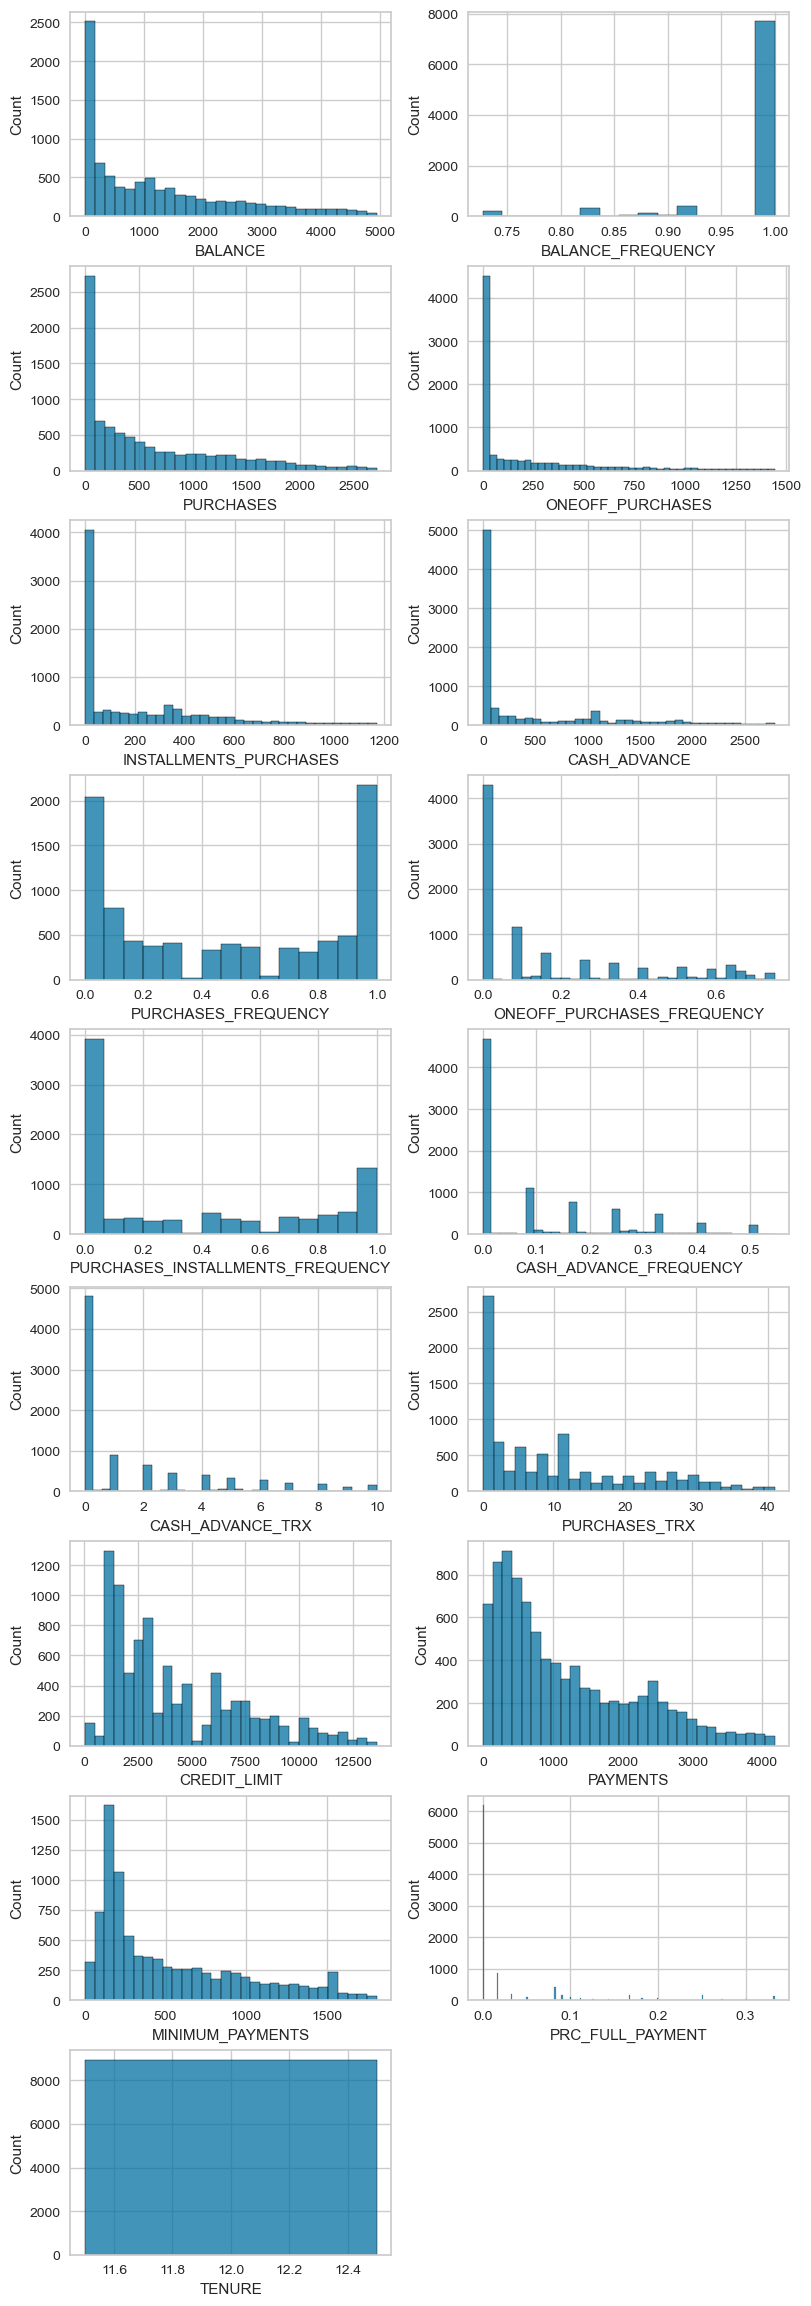

In [19]:
plt.figure(figsize=(8,25), constrained_layout = True)
for  i,col in enumerate(scaled.columns):
    plt.subplot(10,2,i+1)
    sns.histplot(scaled[col])
        
plt.show()

Most of the data is right skewed

### 2.2.1- Standard scaler

In [20]:
SS = StandardScaler()
std_scaled = SS.fit_transform(scaled)
std_scaled = pd.DataFrame(std_scaled, columns=data.columns)
std_scaled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.938493,-2.647994,-0.769179,-0.668201,-0.453152,-0.648900,-0.806649,-0.744440,-0.707409,-0.746803,-0.681834,-0.780929,-1.058708,-0.990388,-0.849850,-0.449531,0.0
1,1.545159,-1.140617,-0.910958,-0.668201,-0.787599,0.879806,-1.221928,-0.744440,-0.917090,1.029217,0.864415,-0.966491,0.877402,2.905708,1.215642,2.720021,0.0
2,0.989506,0.366760,0.238094,1.573112,-0.787599,-0.648900,1.269742,2.116782,-0.917090,-0.746803,-0.681834,0.146882,1.038744,-0.570676,0.230192,-0.449531,0.0
3,0.338673,0.065285,1.316792,0.230208,-0.787599,-0.354376,-1.014290,-0.377618,-0.917090,-0.154799,-0.295272,-0.873710,1.038744,-1.191924,1.303522,-0.449531,0.0
4,-0.328247,0.366760,-0.887180,-0.621819,-0.787599,-0.648900,-1.014290,-0.377618,-0.917090,-0.746803,-0.681834,-0.873710,-0.994171,-0.514482,-0.616734,-0.449531,0.0


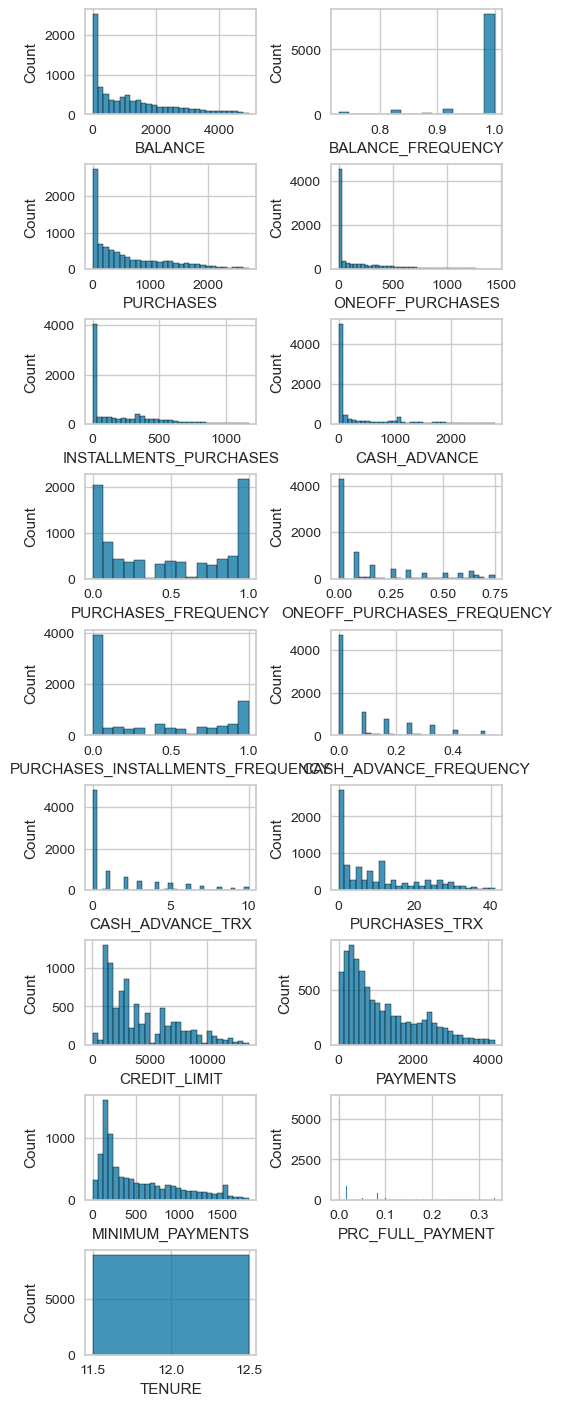

In [21]:
plt.figure(figsize=(5,15), constrained_layout = True)
for i, col in enumerate(std_scaled.columns):
        ax = plt.subplot(10, 2, i+1)
        sns.histplot(scaled[col], ax=ax)
        plt.xlabel(col)
        
plt.show()

The data is still little skewed

### 2.2.2-Minmax Scaler

In [22]:
MMS = MinMaxScaler()
mms_scaled = MMS.fit_transform(scaled)
mms_scaled = pd.DataFrame(mms_scaled, columns=data.columns)

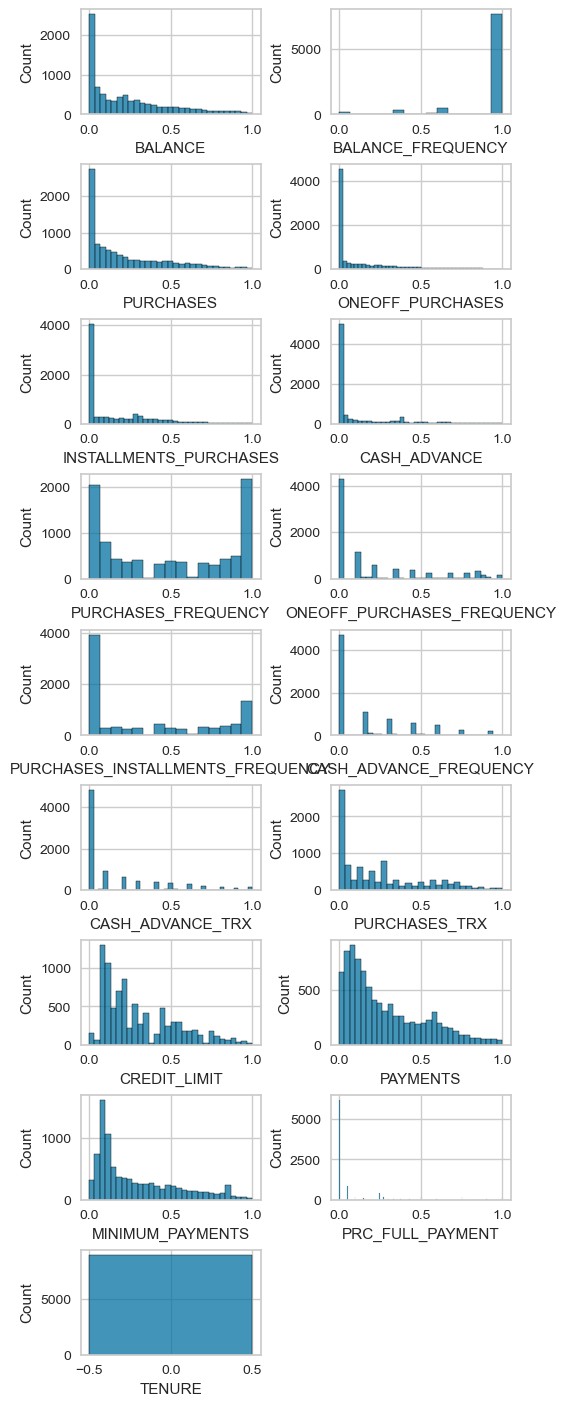

In [23]:
plt.figure(figsize=(5,15), constrained_layout = True)
for i, col in enumerate(mms_scaled.columns):
        ax = plt.subplot(10, 2, i+1)
        sns.histplot(mms_scaled[col], ax=ax)
        plt.xlabel(col)
        
plt.show()

also after minmax scaler the data is still little right skewed

### 2.2.3- Robust scaler

In [24]:
RS = RobustScaler()
robust_scaled = RS.fit_transform(scaled)
robust_scaled = pd.DataFrame(robust_scaled, columns=data.columns)

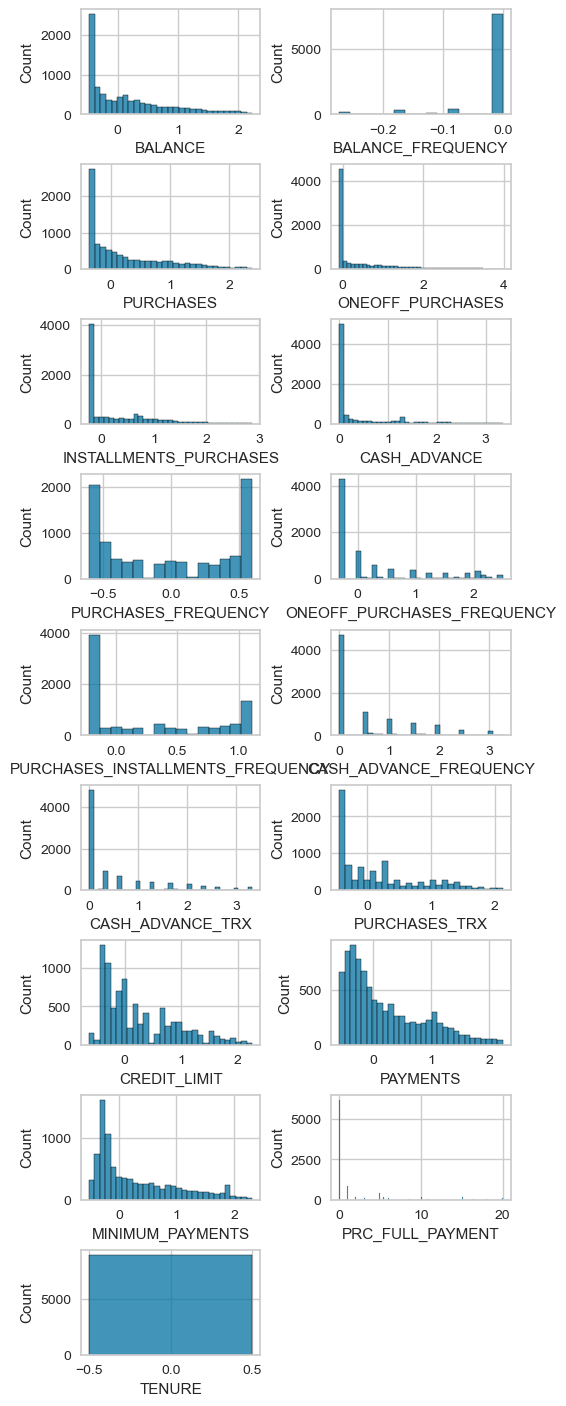

In [25]:
plt.figure(figsize=(5,15), constrained_layout = True)
for i, col in enumerate(robust_scaled.columns):
        ax = plt.subplot(10, 2, i+1)
        sns.histplot(robust_scaled[col], ax=ax)
        plt.xlabel(col)
        
plt.show()

### 2.2.4- log scaler for right skewed  and quantile transformer for left skewed

In [26]:
log_scaled = scaled.copy()
QT = QuantileTransformer(output_distribution='normal')
for col in scaled.columns:
    if col in ["BALANCE_FREQUENCY","PURCHASES_FREQUENCY"]:
        continue
    else:
        log_scaled[col] = np.log(1 + log_scaled[col])
log_scaled.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8.949000e+03
mean,6.089484,0.977881,4.778978,2.924046,3.200165,3.018774,0.490405,0.139441,0.270102,0.092493,0.660033,1.814612,8.076987,6.525424,5.840814,0.028957,2.564949e+00
std,1.933408,0.060313,2.789445,2.933390,2.899488,3.292344,0.401360,0.178129,0.281853,0.119703,0.801013,1.250796,0.791777,1.470053,0.998046,0.062702,1.820867e-13
min,0.000000,0.727273,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.931826,0.000000,0.018982,0.000000,2.564949e+00
25%,4.861779,1.000000,3.703275,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,0.693147,7.378384,5.951379,5.146254,0.000000,2.564949e+00
50%,6.767394,1.000000,5.888878,3.367296,4.499810,0.000000,0.500000,0.080042,0.154151,0.000000,0.000000,2.079442,8.006701,6.753506,5.808272,0.000000,2.564949e+00
75%,7.577219,1.000000,6.933452,5.881488,5.932776,6.724771,0.916667,0.236389,0.559616,0.154151,1.386294,2.890372,8.748464,7.534853,6.696466,0.016529,2.564949e+00
max,8.505346,1.000000,7.905773,7.275401,7.066032,7.932109,1.000000,0.559616,0.693147,0.435318,2.397895,3.737670,9.517899,8.337666,7.501620,0.287682,2.564949e+00


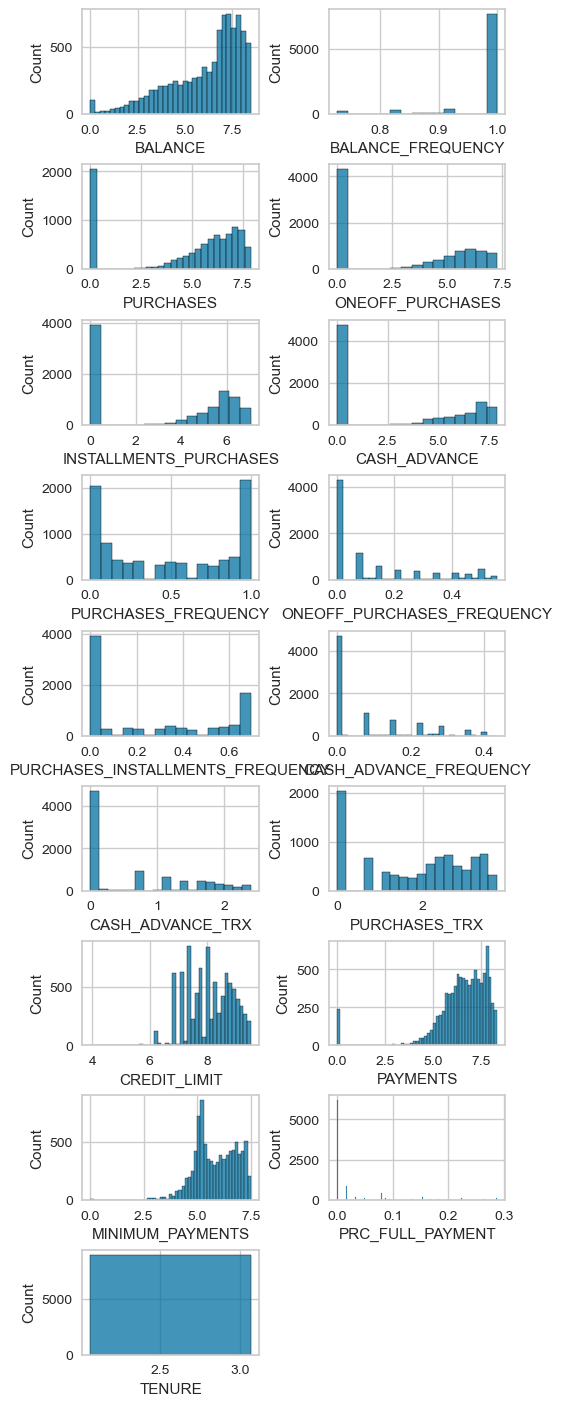

In [27]:
plt.figure(figsize=(5,15), constrained_layout = True)
for i, col in enumerate(log_scaled.columns):
        ax = plt.subplot(10, 2, i+1)
        sns.histplot(log_scaled[col], ax=ax)
        plt.xlabel(col)
        
plt.show()

### 2.2.5- Power Transformer

In [28]:
PS = PowerTransformer()
PS.fit(scaled)
ps_scaled = PS.transform(scaled)
ps_scaled = pd.DataFrame(ps_scaled, columns=data.columns)

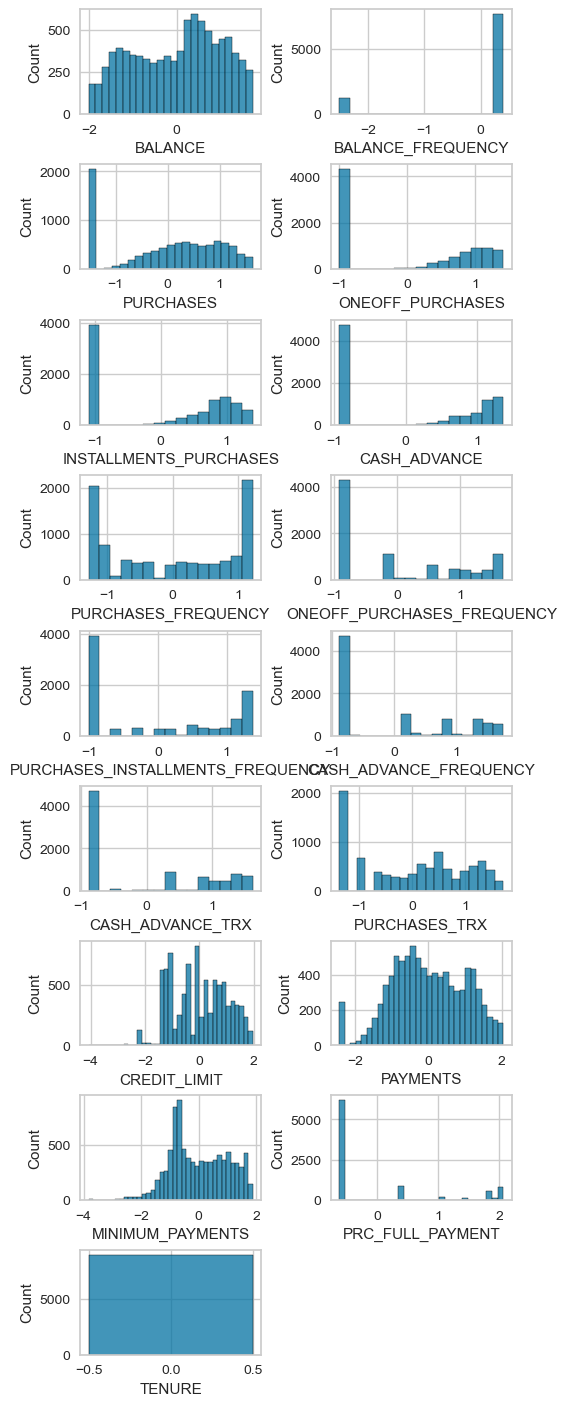

In [29]:
plt.figure(figsize=(5,15), constrained_layout = True)
for i, col in enumerate(ps_scaled.columns):
        ax = plt.subplot(10, 2, i+1)
        sns.histplot(ps_scaled[col], ax=ax)
        plt.xlabel(col)
        
plt.show()

### 2.2.6- Quantile Transformer

In [30]:
QT = QuantileTransformer(output_distribution="normal")
QT.fit(scaled)
QT_scaled = QT.transform(scaled)
QT_scaled = pd.DataFrame(QT_scaled, columns=data.columns)

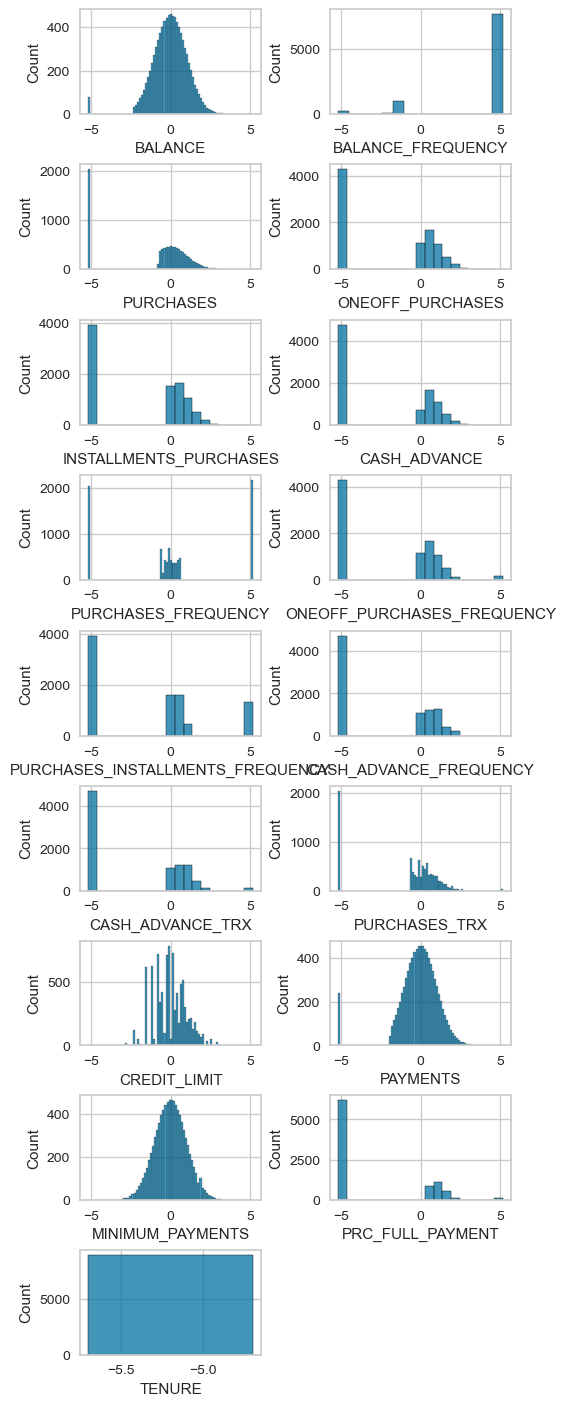

In [31]:
plt.figure(figsize=(5,15), constrained_layout = True)
for i, col in enumerate(ps_scaled.columns):
        ax = plt.subplot(10, 2, i+1)
        sns.histplot(QT_scaled[col], ax=ax)
        plt.xlabel(col)
        
plt.show()

# 3- Dimensional reduction using pca

In [32]:
PCA_data = log_scaled.copy()

<AxesSubplot:>

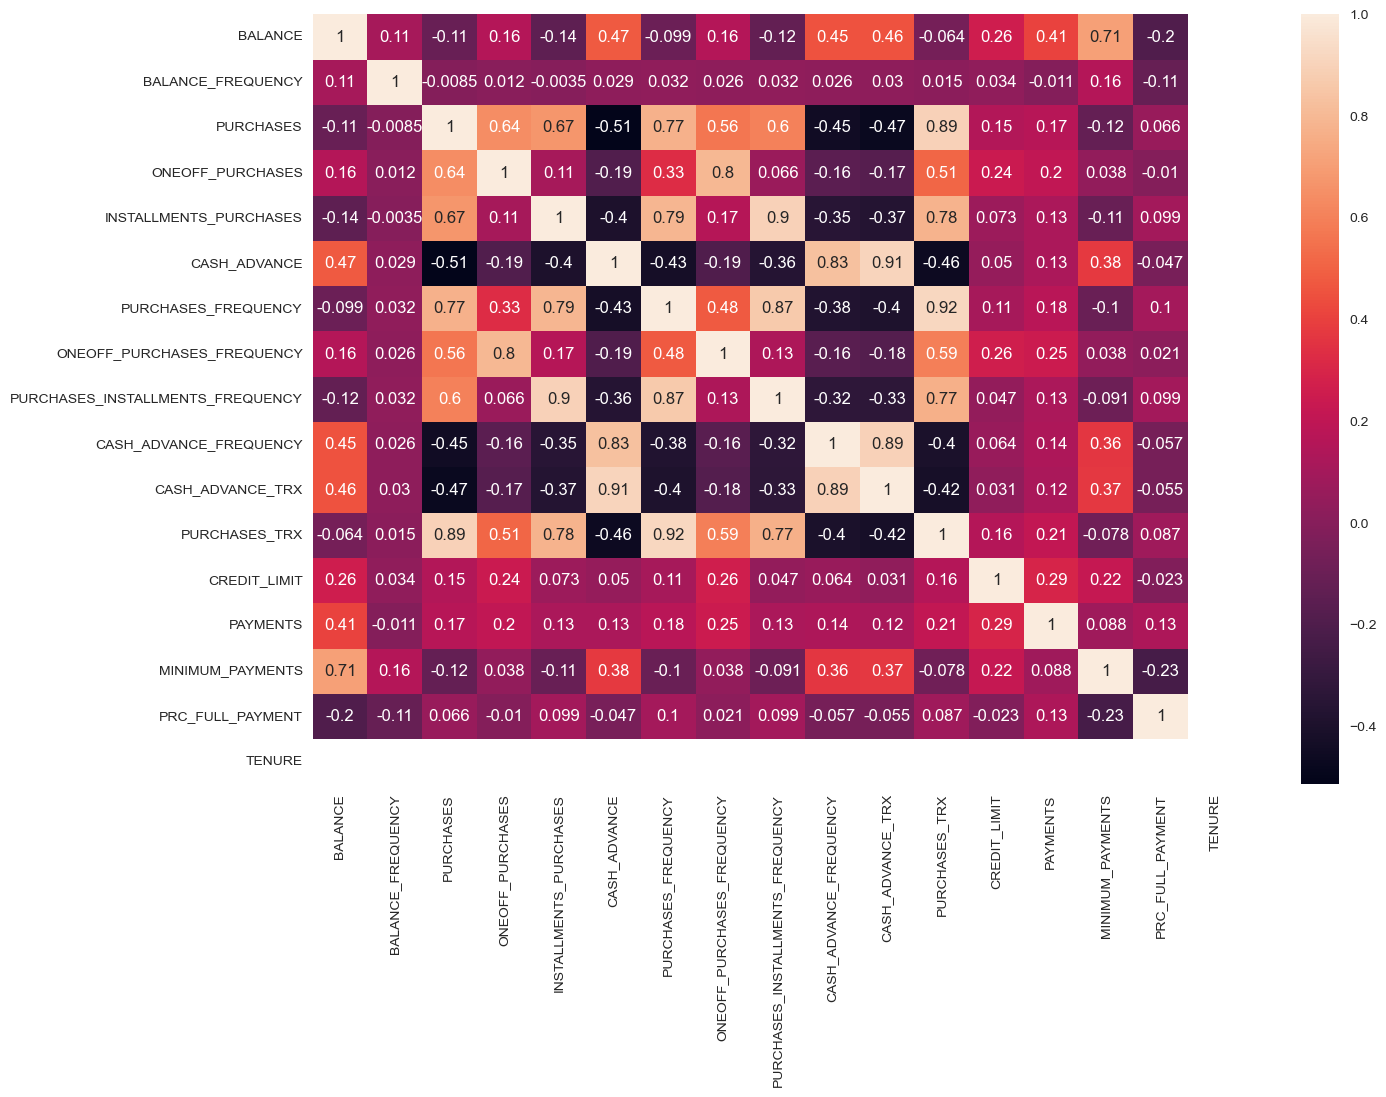

In [33]:
plt.figure(figsize=(15,10))
sns.heatmap(PCA_data.corr(), annot=True)

#### PCA vs Kernel PCA

In [34]:
X_Pca = PCA(n_components=2).fit_transform(PCA_data)
X_KPca = KernelPCA(n_components=2, kernel='rbf').fit_transform(PCA_data)

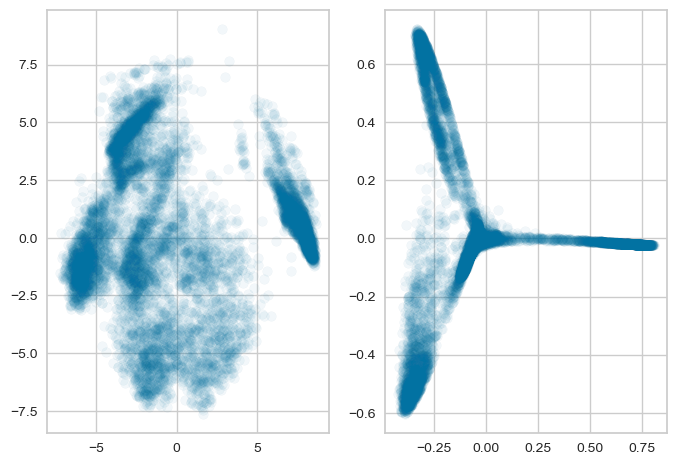

In [35]:
plt.subplot(1,2,1)
plt.scatter(X_Pca[:,0], X_Pca[:,1], alpha=.05)

plt.subplot(1,2,2)
plt.scatter(X_KPca[:,0], X_KPca[:,1], alpha=.05)

### 3.1 PCA

In [69]:
X_pca = PCA(n_components=5).fit_transform(PCA_data)
X_pca.shape

(8949, 5)

### 3.2 Kernel PCA

In [70]:
Kpca = KernelPCA(n_components=5,kernel='rbf', gamma=0.03)
X_reduced = Kpca.fit_transform(PCA_data)

In [71]:
X_reduced.shape

(8949, 5)

In [72]:
Pca_data = pd.DataFrame(X_reduced, columns= [f"PCA{i}" for i in range(X_reduced.shape[1])])
Pca_data.head()

,PCA0,PCA1,PCA2,PCA3,PCA4
0,-0.258683,0.619636,0.122937,0.115166,-0.010538
1,0.727151,0.057806,-0.185721,-0.074991,0.004264
2,-0.162266,-0.332748,-0.019582,0.566555,-0.113603
3,0.028718,-0.092599,0.178087,0.115363,0.099211
4,0.027028,-0.023865,0.049302,0.447396,-0.143696


In [73]:
# pca.explained_variance_ratio_.sum()*100

# 4-Modelling:-

In [74]:
X =X_pca.copy()

In [75]:
def silhouette_plot(model, X, keyword, keyword_range,X_TSNE, plot=True, **kwargs):
    """
    Evaluate Silhouette score for a model with a range of values for keyword argument.
    
    Input:
    ------
    model -- model to be scored
    X -- features
    keyword -- model keyword to use for evaluation
    keyword_range -- range of values for keyword
    plot -- boolean if set to true, then Silhouette score will be plotted
    kwargs -- the rest of the model kwargs (optional)
    """

    for kw_value in keyword_range:
        if plot:
            fig, (ax,ax1) = plt.subplots(1,2)
            fig.set_size_inches(14, 7)

            # The silhouette coefficient can range from -1, 1 but in this example all
            # lie within [-0.1, 1]
            ax.set_xlim([-0.1, 1])
            # The (kw_value+1)*10 is for inserting blank space between silhouette
            # plots of individual clusters, to demarcate them clearly.
            ax.set_ylim([0, len(X) + (kw_value + 1) * 10])

        # Initialize the clusterer with kw_value value and a random generator
        # seed of 10 for reproducibility.
        clusterer = model(**{keyword: kw_value}, **kwargs)
        cluster_labels = clusterer.fit_predict(X)

        # The silhouette_score gives the average value for all the samples.
        # This gives a perspective into the density and separation of the formed
        # clusters
        silhouette_avg = silhouette_score(X, cluster_labels)
        print(
            f"For {keyword} =",
            kw_value,
            "The average silhouette_score is :",
            silhouette_avg,
        )

        if plot:
            # Compute the silhouette scores for each sample
            sample_silhouette_values = silhouette_samples(X, cluster_labels)

            y_lower = 10
            for i in range(len(set(cluster_labels))):
                # Aggregate the silhouette scores for samples belonging to
                # cluster i, and sort them
                ith_cluster_silhouette_values = sample_silhouette_values[
                    cluster_labels == i
                ]

                ith_cluster_silhouette_values.sort()

                size_cluster_i = ith_cluster_silhouette_values.shape[0]
                y_upper = y_lower + size_cluster_i

                ax.fill_betweenx(
                    np.arange(y_lower, y_upper),
                    0,
                    ith_cluster_silhouette_values,
                    alpha=0.7,
                )

                # Label the silhouette plots with their cluster numbers at the middle
                ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

                # Compute the new y_lower for next plot
                y_lower = y_upper + 10  # 10 for the 0 samples

            ax.set_title(f"The silhouette plot for {kw_value} {keyword}.")
            ax.set_xlabel("The silhouette coefficient values")
            ax.set_ylabel("Cluster label")

            # The vertical line for average silhouette score of all the values
            ax.axvline(x=silhouette_avg, color="red", linestyle="--")

            ax.set_yticks([])  # Clear the yaxis labels / ticks
            ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
            
            sns.scatterplot(
            x = X_TSNE[:, 0],
            y = X_TSNE[:, 1],
            hue=cluster_labels,
            palette=sns.color_palette("colorblind", len(set(cluster_labels))),
            alpha=0.3,
            legend="full",
            ax = ax1
            )
            ax1.set_title("The visualization of the clustered data.")
            ax1.set_xlabel("Feature space for the 1st feature")
            ax1.set_ylabel("Feature space for the 2nd feature")

            plt.suptitle(
            f"Silhouette analysis for {model.__name__} clustering on sample data with {keyword} = {kw_value}",
            fontsize=14,
            fontweight="bold",
            )


    if plot:
        plt.show()

In [76]:
X_TSNE = TSNE(n_components=2,
                   perplexity=3,
                   init='pca', 
                   method='barnes_hut', 
                   n_jobs=-1, 
                   random_state=42).fit_transform(X)

## 4.1 KMeans:-

### Choosing number of clusters :-
#### using ELBOW method

In [77]:
inertia_scores = []
silhouette_scores = []
for i in range(2,10):
    Kmeans = KMeans(n_clusters=i, random_state=42)
    Kmeans.fit(X)
    inertia_scores.append(Kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, Kmeans.labels_))

In [78]:
silhouette_scores

[0.404461537842531,
 0.41222270654701615,
 0.4423386647393475,
 0.46590683045703507,
 0.48803481803901544,
 0.5070448269217143,
 0.4732482567592118,
 0.44452223768461585]

In [79]:
np.argmax(silhouette_scores) + 2

7

###### ElBowVizualizer:-

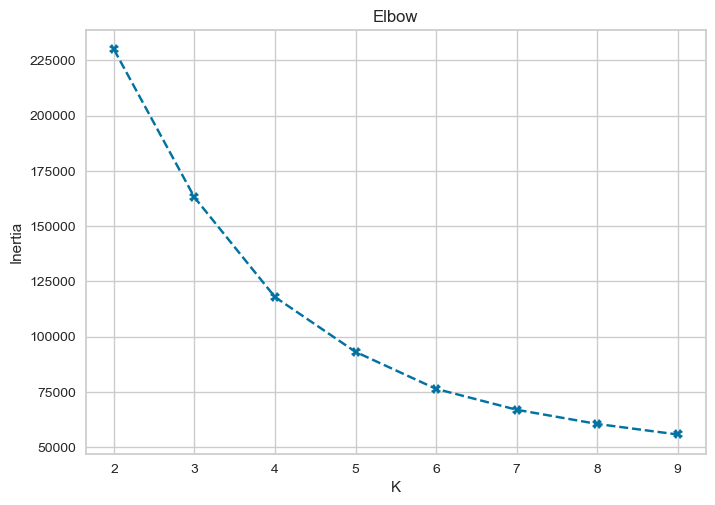

In [80]:
plt.plot(range(2,10), inertia_scores, "--X")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow")
plt.show()

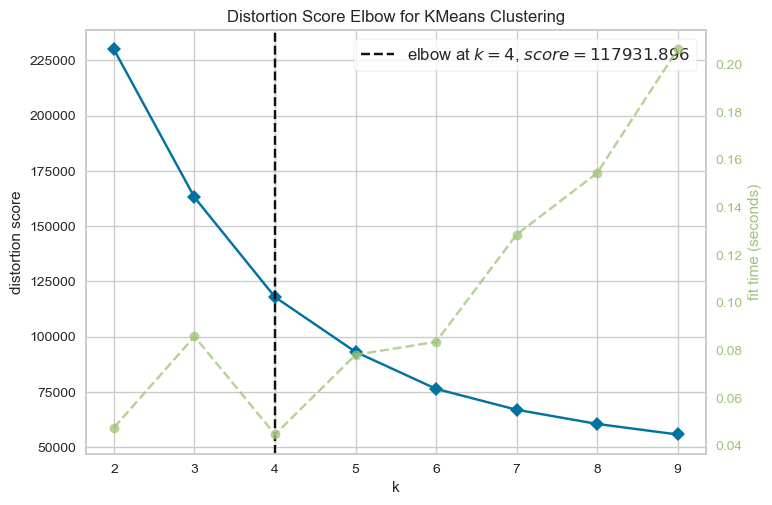

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [81]:
visualizer = KElbowVisualizer(KMeans(random_state=42), k=(2,10))

visualizer.fit(X)        # Fit the data to the visualizer
visualizer.show()  

####  Vizualization for each cluster

For n_clusters = 4 The average silhouette_score is : 0.4423386647393475
For n_clusters = 5 The average silhouette_score is : 0.4659088614230133
For n_clusters = 6 The average silhouette_score is : 0.48803439208381305
For n_clusters = 7 The average silhouette_score is : 0.5070448269217143


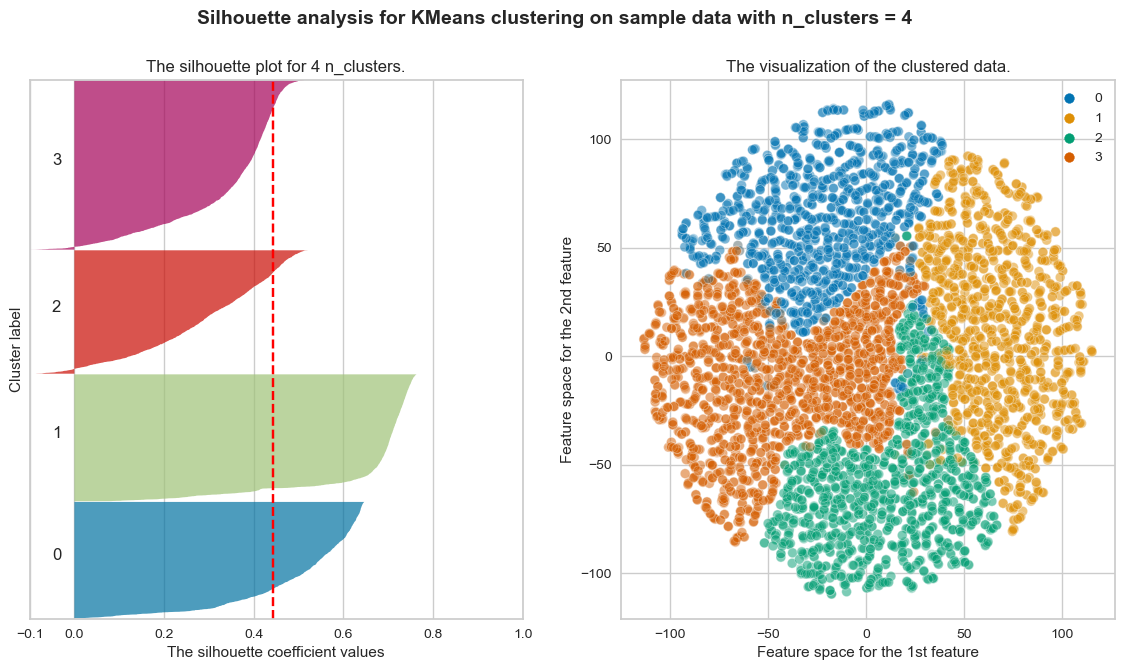

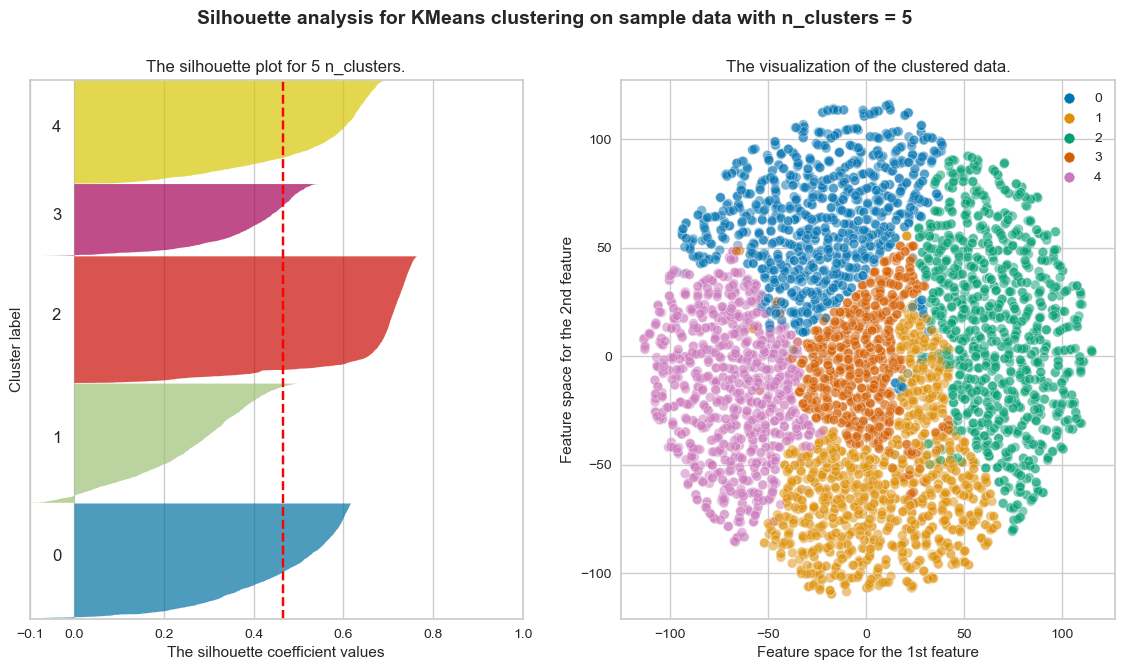

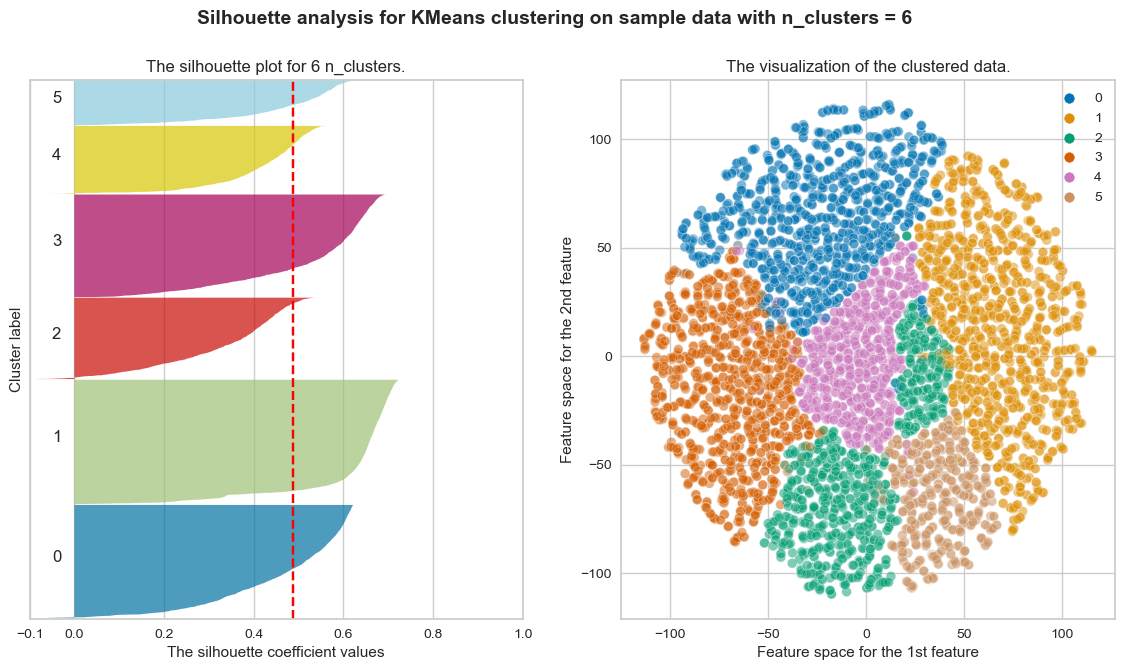

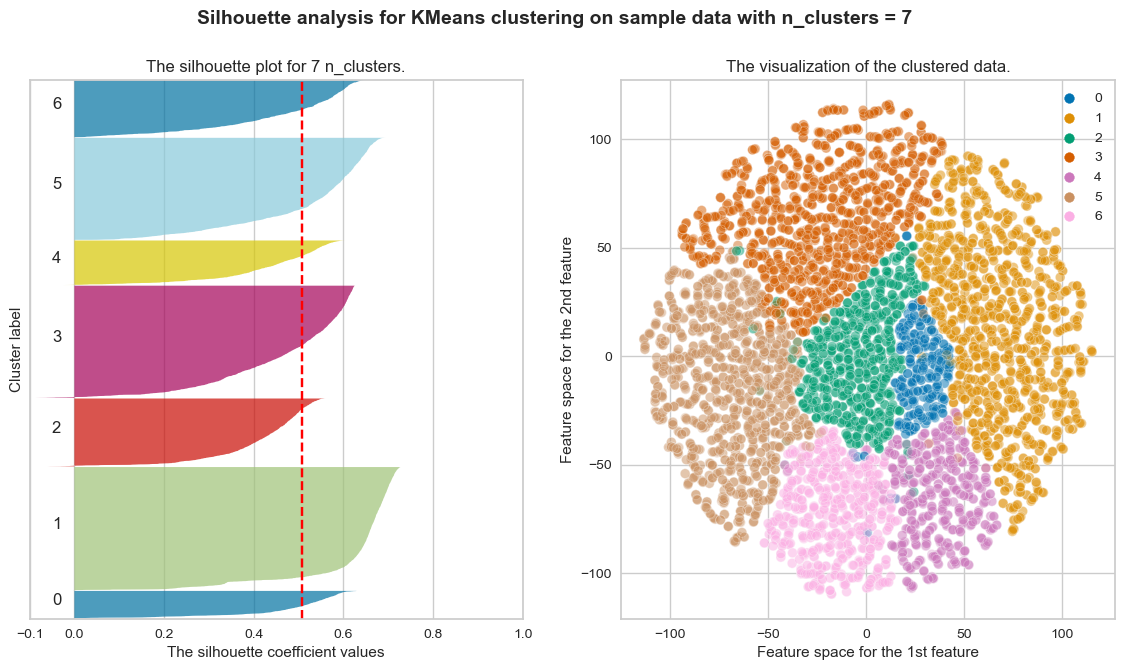

In [82]:
silhouette_plot(KMeans, X, "n_clusters", range(4,8), X_TSNE)

#### Training the model

In [83]:
KMeans_model= KMeans(5, random_state = 42).fit(X)

## 4.2 AgglomerativeClustering

### choosing number of clusters:
#### Using ELBOW method

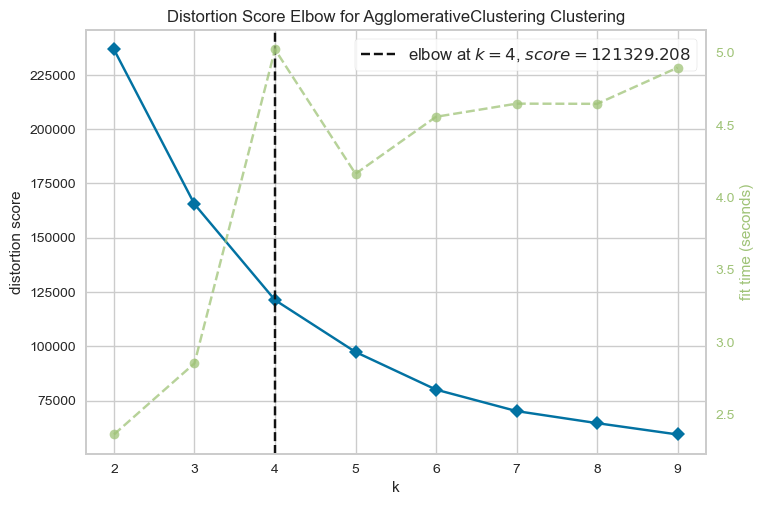

<AxesSubplot:title={'center':'Distortion Score Elbow for AgglomerativeClustering Clustering'}, xlabel='k', ylabel='distortion score'>

In [84]:
visualizer = KElbowVisualizer(AgglomerativeClustering(), k=(2,10))

visualizer.fit(X)        # Fit the data to the visualizer
visualizer.show()  

#### Vizualization of each cluster

For n_clusters = 4 The average silhouette_score is : 0.4334422400072891
For n_clusters = 5 The average silhouette_score is : 0.45504004394275827
For n_clusters = 6 The average silhouette_score is : 0.4778821816087482
For n_clusters = 7 The average silhouette_score is : 0.4983856089972689


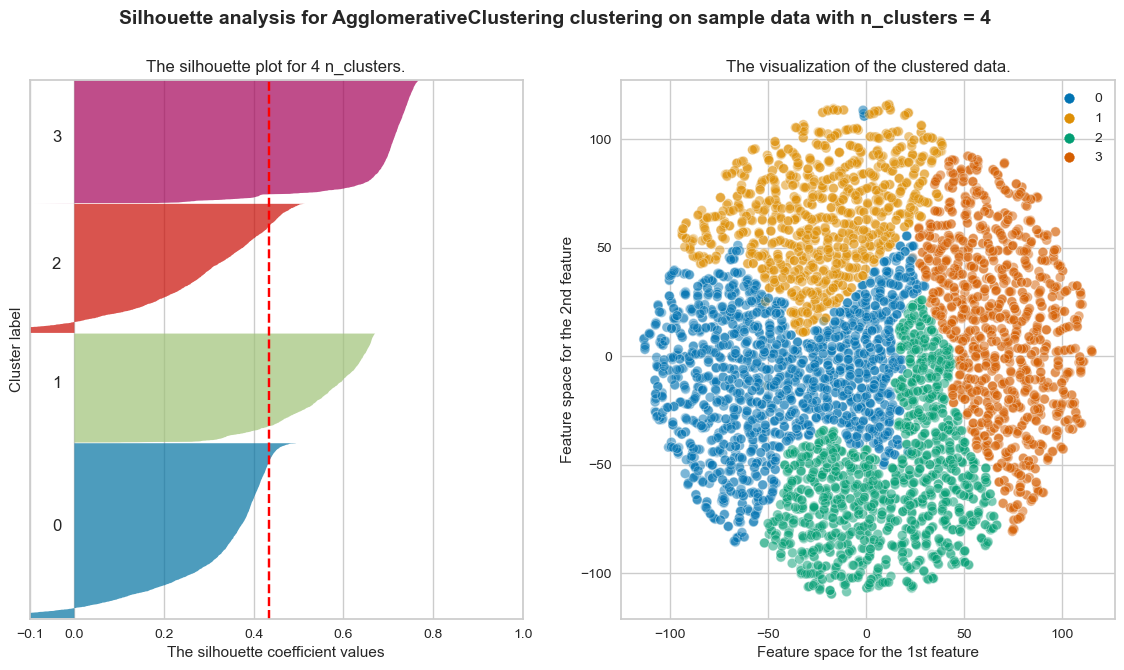

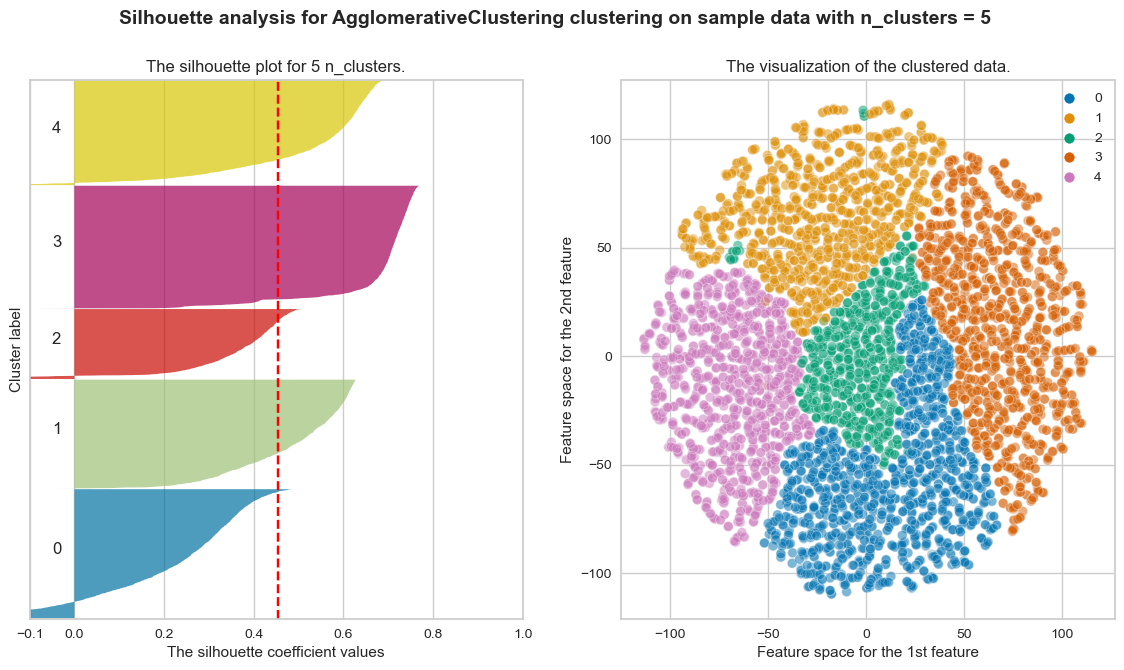

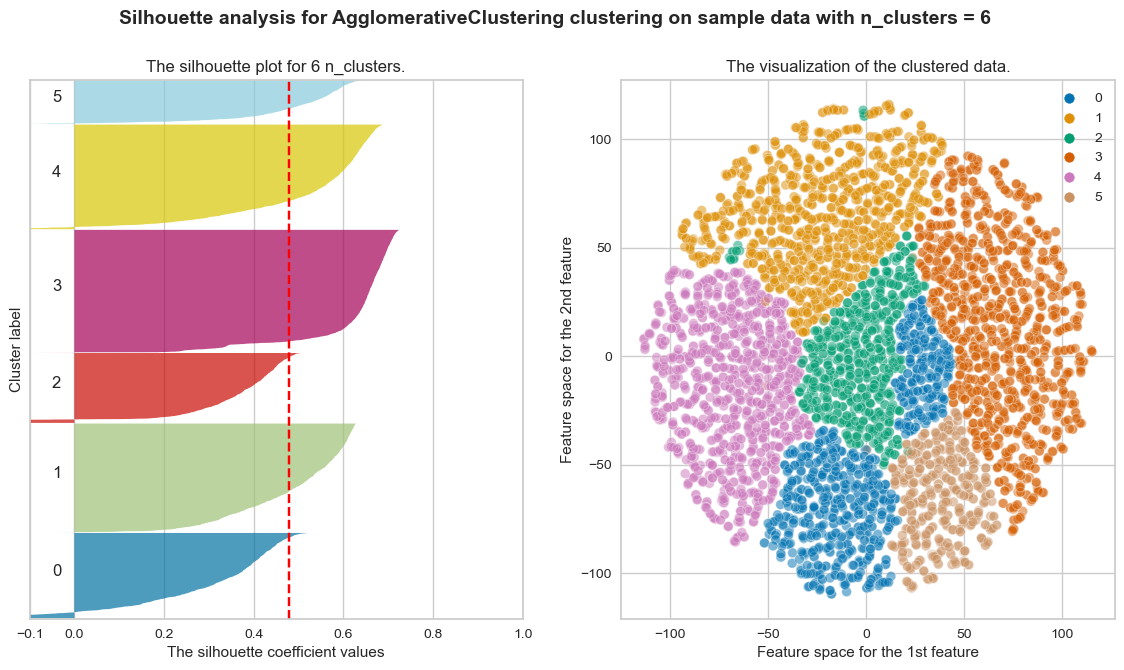

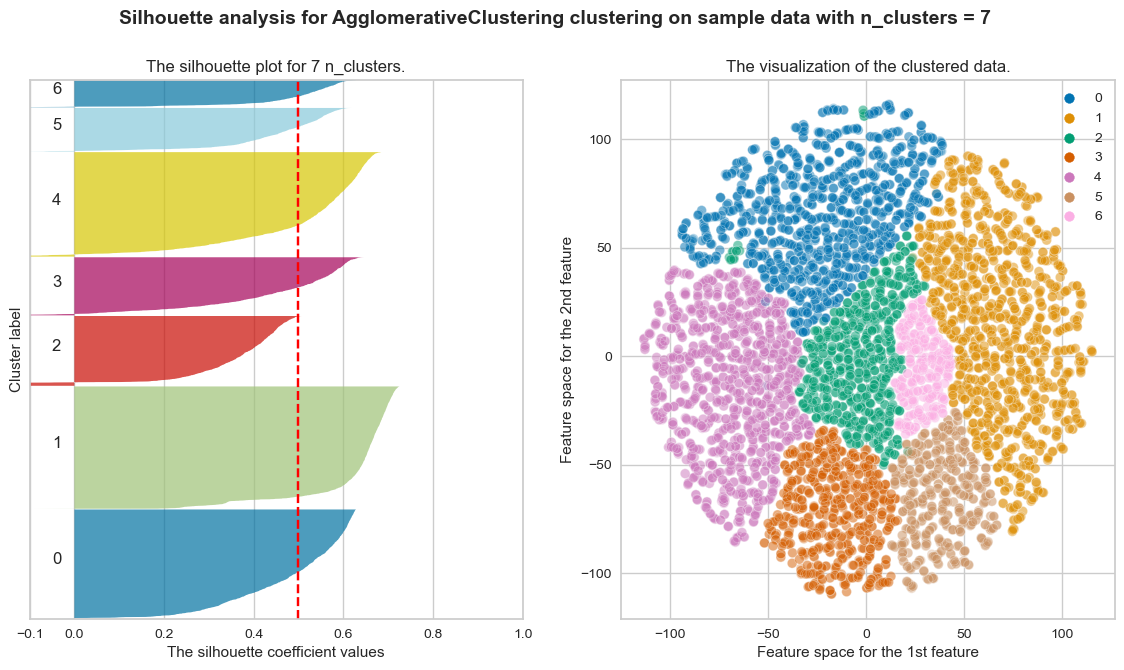

In [85]:
silhouette_plot(AgglomerativeClustering, X, "n_clusters", range(4,8), X_TSNE)

#### Training The model:-

In [86]:
agglomerative_model = AgglomerativeClustering(n_clusters=5).fit(X)

## 4.3 Gaussian Mixture:

### choosing number of clusters:
#### Vizualization of each cluster

For n_components = 4 The average silhouette_score is : 0.4314618484253095
For n_components = 5 The average silhouette_score is : 0.42694170048501034
For n_components = 6 The average silhouette_score is : 0.4550283997884757
For n_components = 7 The average silhouette_score is : 0.4318934024595667


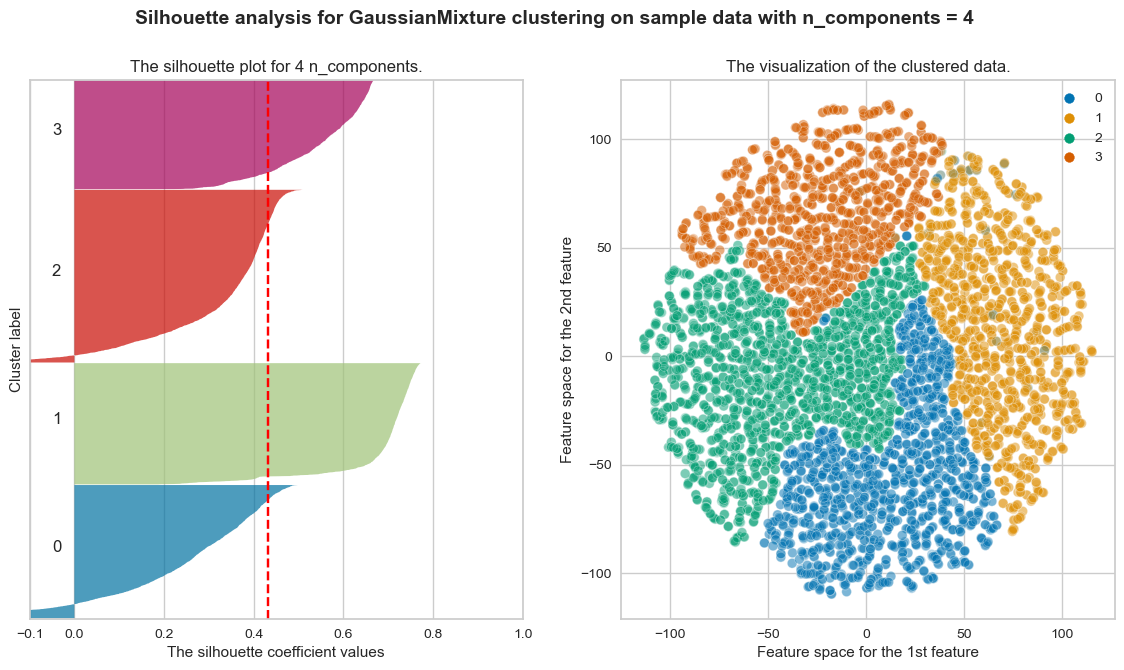

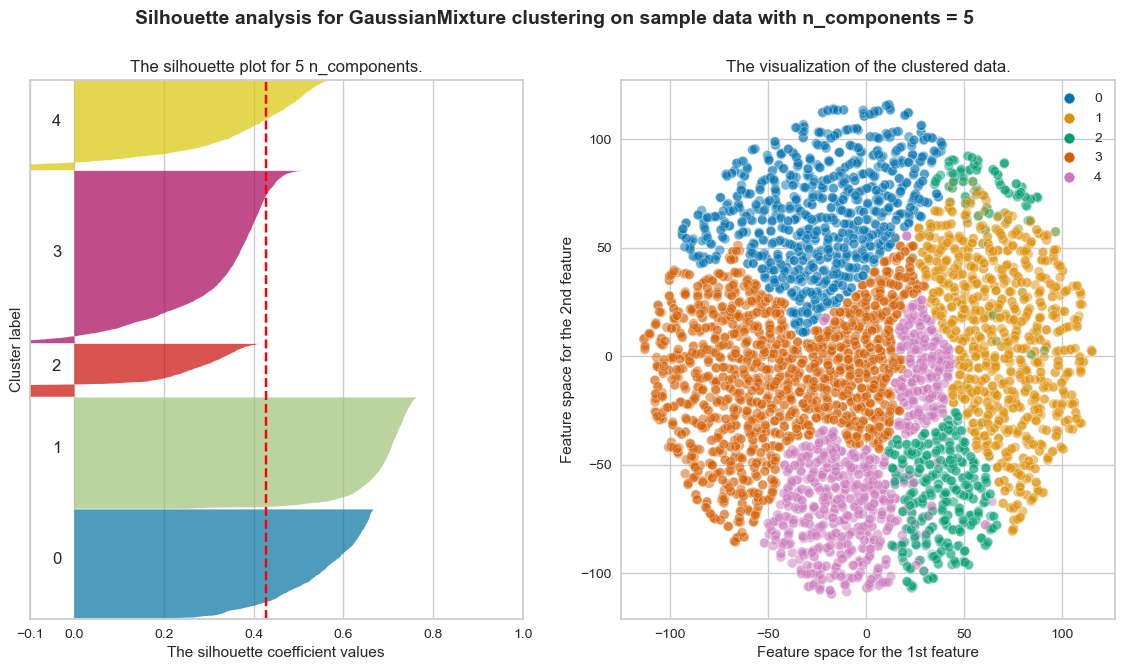

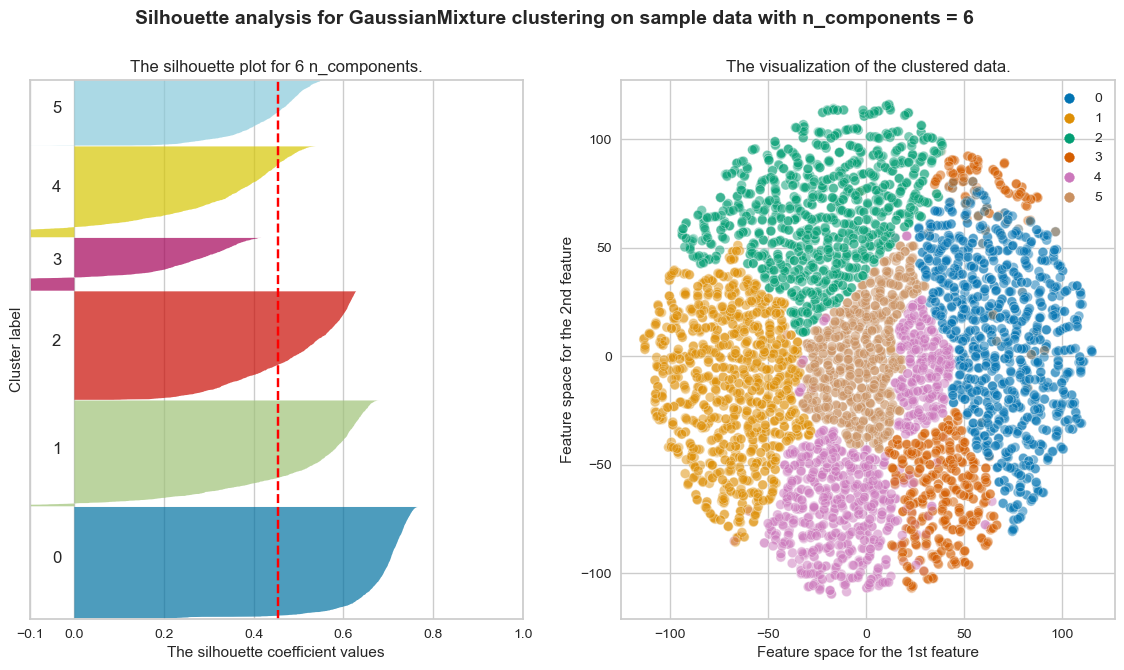

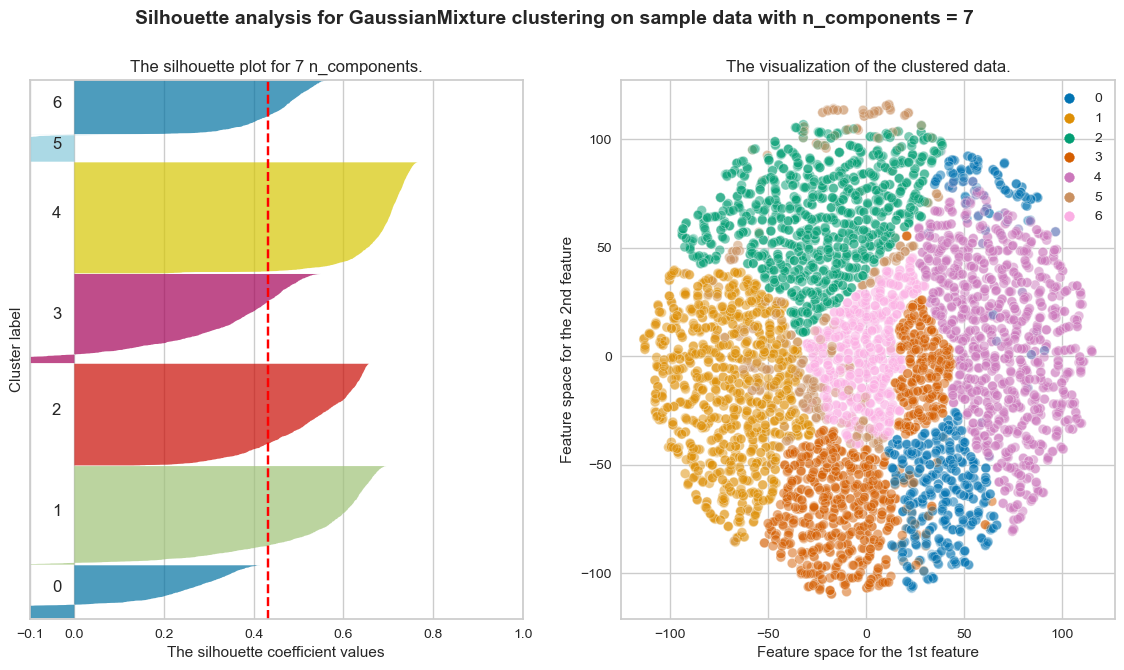

In [87]:
silhouette_plot(GaussianMixture, X, "n_components", range(4,8), X_TSNE)

In [88]:
Gaussian_model = GaussianMixture(n_components=5, random_state=42).fit(X)

## 4.4 Mean shift

### choosing number of clusters:
#### Vizualization of each cluster

In [56]:
# silhouette_plot(MeanShift, X, "bandwidth", [.44,.46,.47,.49,.51,.53,.58], X_TSNE)

### Training The model

In [57]:
Meanshift_model = MeanShift(bandwidth=.51).fit(X)

In [68]:
len(np.unique(Meanshift_model.labels_))

1410

## 4.5 DBSCAN

In [89]:
eps_min = 0.1; eps_max = 13
samples_min = 2; samples_max = 10

In [90]:
db_best_so_far = -1
eps_best_so_far = 0
samples_so_far = 0
i = eps_min
while i <= eps_max :
    for j in range(samples_min, samples_min+1, 1):
        db = DBSCAN(eps = i, min_samples = j).fit(X)
        if len(np.unique(db.labels_)) >1:
            
            score = silhouette_score(X, db.labels_)
        if score > db_best_so_far:
            db_best_so_far = score
            eps_best_so_far = i
            samples_so_far = j
    i+=0.1
db_best_so_far

0.29673118639205975

In [91]:
print(f"The best score for DBSCAN = {db_best_so_far} with eps = {eps_best_so_far} and min_sample = {samples_so_far}")

The best score for DBSCAN = 0.29673118639205975 with eps = 2.400000000000001 and min_sample = 2


### Training and vizualization

In [92]:
db_model = DBSCAN(eps=eps_best_so_far, min_samples=samples_so_far).fit(X)

In [93]:
print(f"Numbers of k = {len(np.unique(db_model.labels_))}")

Numbers of k = 14


In [63]:
# sns.scatterplot(
#             x = X_TSNE[:, 0],
#             y = X_TSNE[:, 1],
#             hue=db_model.labels_,
#             palette=sns.color_palette("colorblind", len(set(db_model.labels_))),
#             alpha=0.3,
#             legend="full",
#             )

## 5-Comparing silhouette and Davies-Bouldin Index for the models
### 5.1 Silhouette scores:

In [94]:
silhouette_scores = []

for model in [KMeans_model, agglomerative_model, Gaussian_model]:
    try: 
        score = silhouette_score(X, model.labels_)
    except:
        score = silhouette_score(X, model.predict(X))
    
        
    silhouette_scores.append((model.__class__.__name__, score))

In [95]:
sorted(silhouette_scores, key=lambda x: -x[1])

[('KMeans', 0.46590683045703507),
 ('AgglomerativeClustering', 0.45504004394275827),
 ('GaussianMixture', 0.451687306400561)]

### 5.2: Davies-Bouldin Index

In [96]:
DB_scores = []

for model in [KMeans_model, agglomerative_model, Gaussian_model]:
    try: 
        score = davies_bouldin_score(X, model.labels_)
    except:
        score = davies_bouldin_score(X, model.predict(X))
        
    DB_scores.append((model.__class__.__name__, score))

In [97]:
sorted(DB_scores, key=lambda x: x[1])

[('KMeans', 0.8297613724213406),
 ('AgglomerativeClustering', 0.8689012096699814),
 ('GaussianMixture', 0.8730469878757219)]